# ShiftWatch: from training data to a monitoring decision

**Question:** how do synthetic changes in incoming numerical data affect a classifier,
and do distribution alerts tell the same story as prediction metrics?

This notebook makes the project's evaluation inspectable: training-only exploration,
a dummy baseline, cross-validation, untouched holdout errors, and explicitly synthetic
stress tests. It executes the same Python experiment used by the dashboard instead of
maintaining a second training implementation. All tables and figures below are computed.

**Data:** 178 UCI Wine observations, 13 numerical measurements, three cultivar labels.
This small educational dataset is not a production deployment or evidence of business impact.
See the [model card](../docs/model-card.md) and [methodology](../docs/methodology.md).

**Run:** follow the notebook instructions in the [README](../README.md#analysis-notebook).
The notebook runs from either the repository root or this directory. It does not download
data, write reports, or fit preprocessing on held-out rows.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.datasets import load_wine
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Use this checkout when run directly, including from the notebooks directory.
ROOT = Path.cwd().resolve()
if not (ROOT / "src/shiftwatch").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "src/shiftwatch").is_dir(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(ROOT / "src"))
from shiftwatch.experiment import run_experiment

SEED = 42
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})
pd.set_option("display.max_columns", 14)

## 1. Reserve the test split before exploration

The 30% holdout and seed are fixed by the experiment. Stratification preserves class
representation. Only the training partition is explored below. The test partition is
reserved for evaluation after model selection; it is not used to choose features,
preprocessing, hyperparameters, or thresholds.

In [2]:
wine = load_wine(as_frame=True)
x_train, x_test, y_train, y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, stratify=wine.target, random_state=SEED
)
assert set(x_train.index).isdisjoint(x_test.index)
assert len(x_train) + len(x_test) == len(wine.data)
print(f"Training: {len(x_train)} rows; reserved holdout: {len(x_test)} rows")
class_counts = y_train.value_counts().sort_index().rename("training_rows").to_frame()
class_counts.index = [f"Cultivar {i + 1}" for i in class_counts.index]
class_counts["training_share"] = class_counts.training_rows / len(y_train)
display(class_counts.round(3))
display(x_train.describe().T[["count", "mean", "std", "min", "max"]].round(3))
print("Missing training values:", int(x_train.isna().sum().sum()))

Training: 124 rows; reserved holdout: 54 rows


,training_rows,training_share
Cultivar 1,41,0.331
Cultivar 2,50,0.403
Cultivar 3,33,0.266


,count,mean,std,min,max
alcohol,124.0,12.956,0.811,11.03,14.83
malic_acid,124.0,2.287,1.060,0.74,5.80
ash,124.0,2.363,0.269,1.36,3.22
alcalinity_of_ash,124.0,19.669,3.387,10.60,30.00
magnesium,124.0,100.040,15.234,70.00,162.00
total_phenols,124.0,2.293,0.627,0.98,3.88
flavanoids,124.0,2.007,0.955,0.34,3.74
nonflavanoid_phenols,124.0,0.360,0.118,0.13,0.63
proanthocyanins,124.0,1.606,0.579,0.42,3.58
color_intensity,124.0,4.994,2.381,1.28,13.00


Missing training values: 0


### Feature scale and association

Alcohol and proline illustrate the different measurement scales. The correlation
matrix includes training features only; target labels are not numerical features.
Correlation is descriptive, not a causal claim or proof of a useful model.
The experiment's predefined pipeline standardizes features for logistic regression.
Its median imputer also allows the later missing-data stress test.

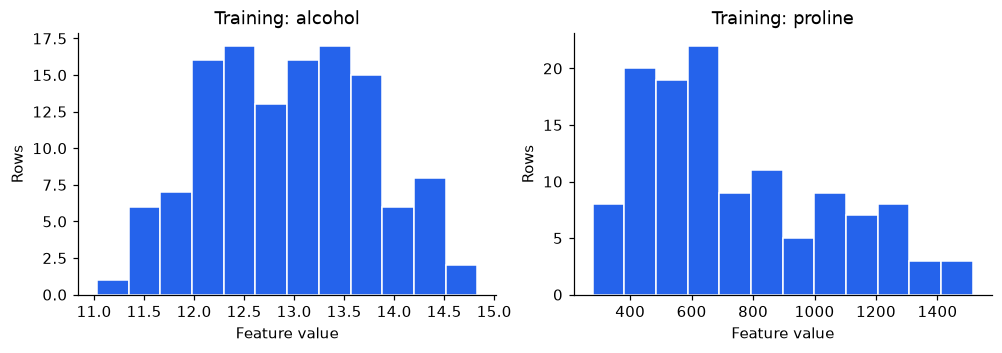

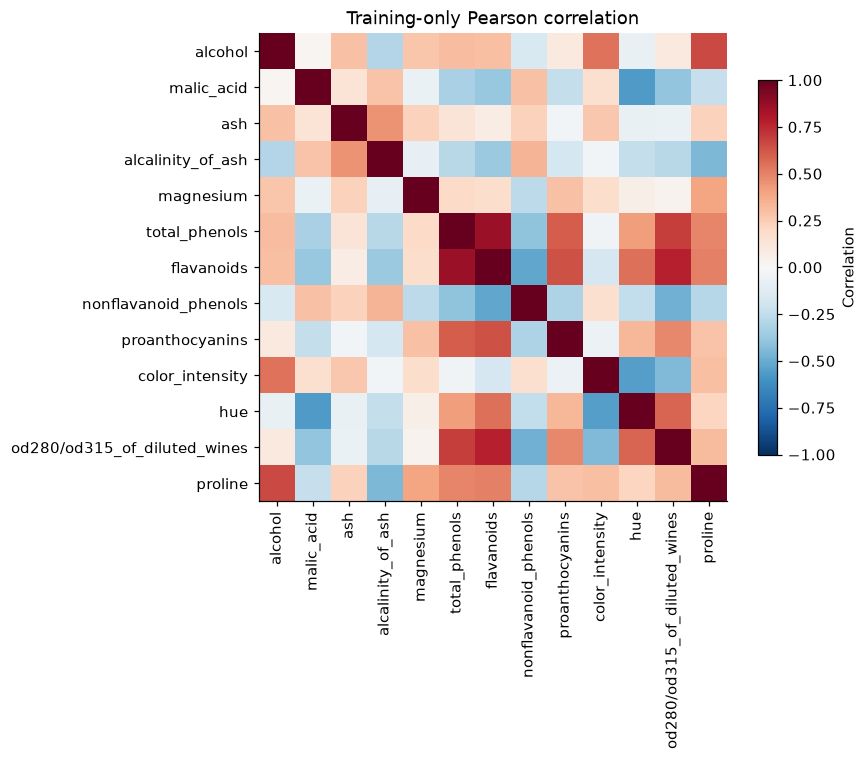

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.1), constrained_layout=True)
for ax, feature in zip(axes, ["alcohol", "proline"]):
    ax.hist(x_train[feature], bins=12, color="#2563eb", edgecolor="white")
    ax.set(title=f"Training: {feature}", xlabel="Feature value", ylabel="Rows")
plt.show()

corr = x_train.corr()
fig, ax = plt.subplots(figsize=(8.4, 6.8), constrained_layout=True)
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr)), corr.columns, rotation=90)
ax.set_yticks(range(len(corr)), corr.index)
ax.set_title("Training-only Pearson correlation")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
plt.show()

## 2. Select with training cross-validation

The production function below evaluates three predefined candidates using the same
five stratified folds and macro F1. Each fold fits its own imputer and scaler through
a scikit-learn pipeline. Macro F1 gives each class equal weight. The dummy classifier
shows what a most-frequent-class rule achieves.

Selection uses the largest mean CV score, not holdout accuracy. The fold standard
deviation describes variation across these folds; it is not a confidence interval.
This one small CV comparison does not establish that the selected algorithm is always better.

,cv_mean,cv_std,selected
name,,,
Logistic regression,0.9834,0.0203,True
Random forest,0.9760,0.0321,False
Dummy baseline,0.1916,0.0022,False


Selected using training CV: Logistic regression


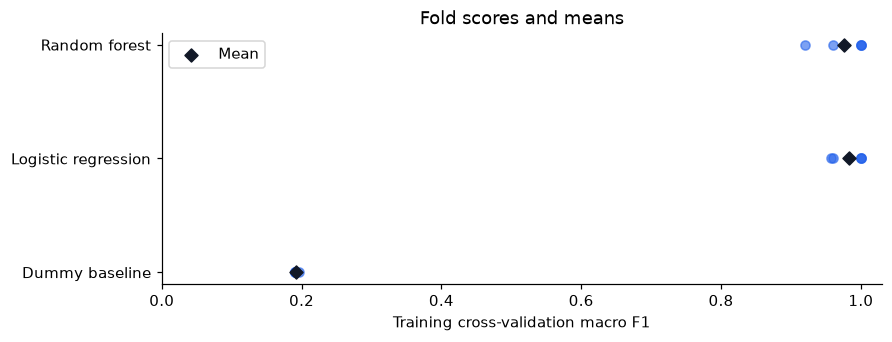

In [4]:
report = run_experiment(seed=SEED)
assert report["split"]["train_indices"] == x_train.index.tolist()
assert report["split"]["test_indices"] == x_test.index.tolist()
models = pd.DataFrame(report["models"]).set_index("name")
cv_table = models[["cv_mean", "cv_std"]].copy()
cv_table["selected"] = cv_table.index == report["selected_model"]
display(cv_table.sort_values("cv_mean", ascending=False).round(4))
print("Selected using training CV:", report["selected_model"])

fig, ax = plt.subplots(figsize=(8, 3), constrained_layout=True)
for position, (name, row) in enumerate(models.iterrows()):
    ax.scatter(row.cv_folds, [position] * len(row.cv_folds), color="#2563eb", alpha=0.6)
    ax.scatter(row.cv_mean, position, marker="D", color="#111827", label="Mean" if position == 0 else None)
ax.set_yticks(range(len(models)), models.index)
ax.set(xlabel="Training cross-validation macro F1", xlim=(0, 1.03), title="Fold scores and means")
ax.legend()
plt.show()

## 3. Inspect the untouched holdout, including errors

Only now interpret prediction performance on the 54 reserved rows. The confusion
matrix shows where mistakes occur; accuracy alone hides this. The reported 95%
percentile bootstrap interval resamples correctness on these test rows with the
already fitted model. It does not include uncertainty from retraining or model selection.
A high score on 54 observations should not be generalized to new domains.

,Untouched holdout
accuracy,0.9815
macro_f1,0.9829
log_loss,0.0778
bootstrap_95%_lower,0.9444
bootstrap_95%_upper,1.0000


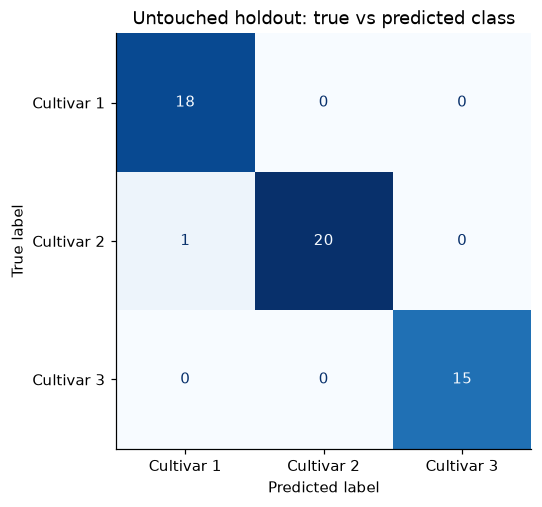

,test_rows,misclassified,recall
Cultivar 1,18,0,1.000
Cultivar 2,21,1,0.952
Cultivar 3,15,0,1.000


In [5]:
reference = next(s for s in report["scenarios"] if s["id"] == "reference")
metrics = reference["metrics"]
display(pd.Series({
    "accuracy": metrics["accuracy"],
    "macro_f1": metrics["macro_f1"],
    "log_loss": metrics["log_loss"],
    "bootstrap_95%_lower": metrics["accuracy_ci"][0],
    "bootstrap_95%_upper": metrics["accuracy_ci"][1],
}).round(4).to_frame("Untouched holdout"))

matrix = np.asarray(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5.4, 4.5), constrained_layout=True)
ConfusionMatrixDisplay(matrix, display_labels=metrics["class_labels"]).plot(
    ax=ax, colorbar=False, cmap="Blues", values_format="d"
)
ax.set_title("Untouched holdout: true vs predicted class")
plt.show()
support = matrix.sum(axis=1)
error_summary = pd.DataFrame({
    "test_rows": support,
    "misclassified": support - matrix.diagonal(),
    "recall": np.divide(matrix.diagonal(), support),
}, index=metrics["class_labels"])
display(error_summary.round(3))

## 4. Separate data alerts from prediction degradation

The model stays fixed. Moderate and severe scenarios add 0.75 and 2 training standard
deviations to four features. The missingness scenario removes about 30% of values from
three features using a fixed seed. All reuse the original holdout labels and rows.
They are paired, synthetic stress tests, not independent new test datasets or measured
future traffic. Changing chemistry while retaining labels is a simplifying assumption.

Distribution alerts require both PSI ≥ 0.20 and BH-adjusted KS p ≤ 0.05; quality alerts
flag at least a five-percentage-point absolute missingness change. Thresholds are fixed
before inspecting results, and are configurable heuristics rather than universal guarantees.

,synthetic,accuracy,macro_f1,log_loss,features_flagged
scenario,,,,,
Untouched holdout,False,0.9815,0.9829,0.0778,0
Moderate shift,True,0.8333,0.8377,0.3578,4
Severe shift,True,0.5370,0.4788,2.2358,4
Missing data,True,0.9815,0.9829,0.1126,3


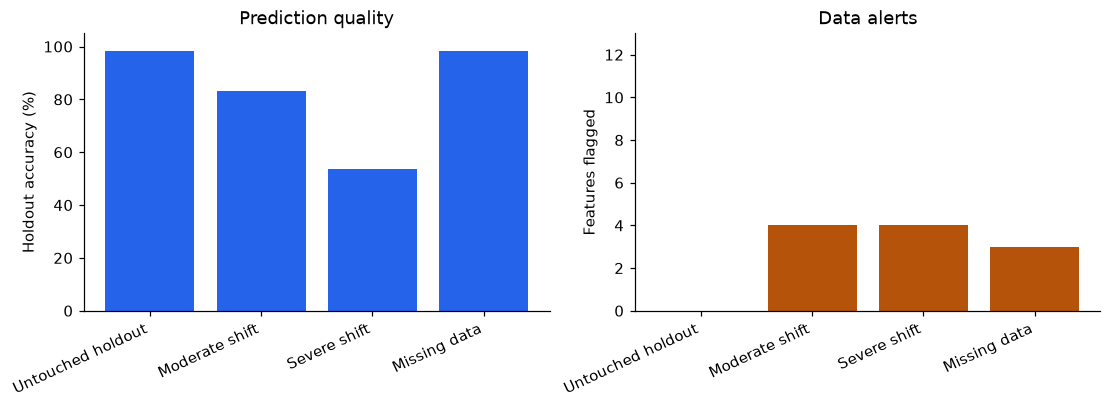

,scenario,feature,PSI,adjusted_KS_p,missing_delta,distribution_alert,quality_alert
0,Moderate shift,alcohol,0.8006,0.0003,0.0000,True,False
1,Moderate shift,flavanoids,0.8491,0.0058,0.0000,True,False
2,Moderate shift,color_intensity,0.9641,0.0000,0.0000,True,False
3,Moderate shift,proline,0.9202,0.0000,0.0000,True,False
4,Severe shift,alcohol,2.3135,0.0000,0.0000,True,False
5,Severe shift,flavanoids,2.1735,0.0000,0.0000,True,False
6,Severe shift,color_intensity,2.7938,0.0000,0.0000,True,False
7,Severe shift,proline,2.4238,0.0000,0.0000,True,False
8,Missing data,alcohol,0.1622,0.9292,0.2963,False,True
9,Missing data,flavanoids,0.3995,0.9292,0.2963,False,True


In [6]:
summary = pd.DataFrame([
    {"scenario": s["name"], "synthetic": s["synthetic"],
     "accuracy": s["metrics"]["accuracy"], "macro_f1": s["metrics"]["macro_f1"],
     "log_loss": s["metrics"]["log_loss"], "features_flagged": s["drift"]["alert_count"]}
    for s in report["scenarios"]
]).set_index("scenario")
display(summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), constrained_layout=True)
positions = np.arange(len(summary))
axes[0].bar(positions, summary.accuracy * 100, color="#2563eb")
axes[0].set(ylabel="Holdout accuracy (%)", ylim=(0, 105), title="Prediction quality")
axes[1].bar(positions, summary.features_flagged, color="#b45309")
axes[1].set(ylabel="Features flagged", ylim=(0, len(x_train.columns)), title="Data alerts")
for ax in axes:
    ax.set_xticks(positions, summary.index, rotation=25, ha="right")
plt.show()

alerts = pd.DataFrame([
    {"scenario": s["name"], "feature": f["name"], "PSI": f["psi"],
     "adjusted_KS_p": f["q_value"], "missing_delta": f["missing_delta"],
     "distribution_alert": f["distribution_alert"], "quality_alert": f["quality_alert"]}
    for s in report["scenarios"] for f in s["drift"]["features"] if f["alert"]
])
display(alerts.round(4))

### Interpretation and next decision

- The severe perturbation lowers accuracy substantially while flagging the same number
  of features as the moderate perturbation. Alert counts do not measure the size of a
  performance drop; inspect the feature statistics and prediction metrics together.
- Missingness alerts appear even though accuracy matches the untouched holdout in this
  run. A data-quality problem need not immediately produce a classification error.
- A real monitor would first validate ingestion and feature definitions, then obtain
  representative labels to assess performance. An alert alone does not justify retraining.
- The untouched split has no flagged features under these defaults. This single result
  does not estimate the false-alert rate of repeated monitoring.

## 5. Reproduction and limitations

The output records package versions, the dataset fingerprint, and exact split indices.
The repository's reproduction checker compares numerical results with a tolerance while
allowing environment metadata to differ. CI also tests split isolation and preprocessing
leakage. This notebook does not tune thresholds or claim that the scenarios establish
causal effects, calibrated probabilities, temporal robustness, or production readiness.

In [7]:
print("Dataset SHA-256:", report["dataset"]["sha256"])
display(pd.Series(report["environment"], name="Executed environment").to_frame())
print("Seed:", report["seed"])
print("All analysis cells completed using the repository experiment.")

Dataset SHA-256: 380c9275f43fdaeada5c66ef9c7a6e70bb36b6516570c81622e4ab99546366af


,Executed environment
python,3.12.14
numpy,2.5.3
scipy,1.18.1
sklearn,1.9.0


Seed: 42
All analysis cells completed using the repository experiment.


## Extend the analysis yourself

1. Before rerunning, predict which two cultivars are easiest to confuse and explain why.
2. Change the seed in a separate experiment, rerun everything, and report variation
   across all seeds you chose in advance. Do not select only the best run.
3. Add a held-out dataset from a genuinely different collection process and document
   its provenance, label availability, and feature compatibility before comparing it.
4. Investigate class-specific errors before changing the model. If you use the holdout
   to develop a fix, reserve fresh evaluation data for the revised model.

**Sources:** [Wine dataset and attribution](https://archive.ics.uci.edu/dataset/109/wine),
[scikit-learn leakage guidance](https://scikit-learn.org/stable/common_pitfalls.html),
[experiment source](../src/shiftwatch/experiment.py), [drift source](../src/shiftwatch/drift.py).
Wine is licensed under CC BY 4.0; see the repository README for attribution and transformations.